# 🚀 Boosting Algorithms - Loan Default Prediction

This notebook demonstrates the application of **Boosting Ensemble Machine Learning** (AdaBoost Classifier) on the `Loan_default.csv` dataset to predict loan default risks.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score,
                             confusion_matrix, precision_recall_curve)

# 1. Load dataset
df = pd.read_csv('Loan_default.csv')

if 'LoanID' in df.columns:
    df = df.drop(columns=['LoanID'])

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (255347, 17)


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [34]:
# 2. Encode categorical variables
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# 3. Features and Target split
X = df.drop(columns=['Default'])
y = df['Default']

# Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

Training set shape: (204277, 16)
Testing set shape:  (51070, 16)


In [35]:
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
ada.fit(X_train, y_train)

y_pred = ada.predict(X_test)
y_pred_proba = ada.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-12)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

y_pred = (y_pred_proba >= best_threshold).astype(int)

print("=== AdaBoost Classifier Evaluation ===")
print(f"Accuracy:      {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision:     {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:        {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1 Score:      {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}\n")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

=== AdaBoost Classifier Evaluation ===
Accuracy:      0.7904
Precision:     0.2734
Recall:        0.4854
F1 Score:      0.3498
ROC-AUC Score: 0.7366

Confusion Matrix:
 [[37486  7653]
 [ 3052  2879]]


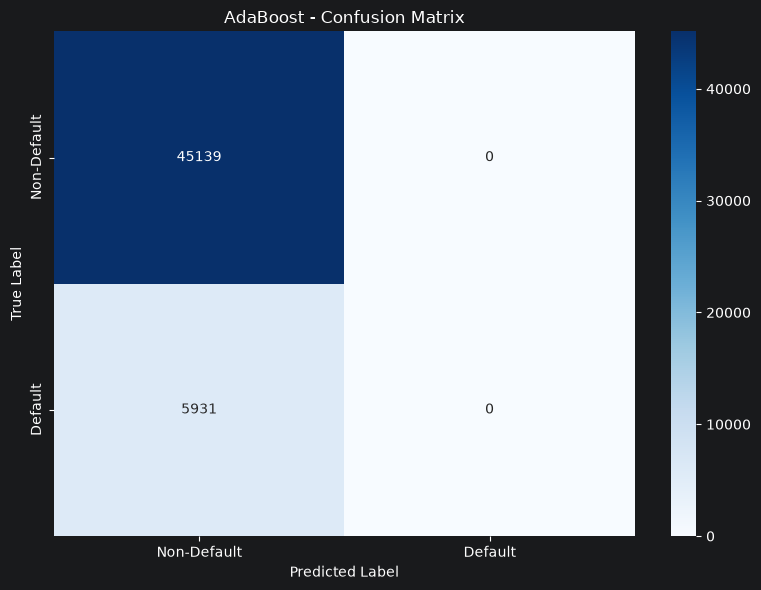

In [23]:
# 6. Plot Confusion Matrix
plt.figure(figsize=(8, 6))

# Calculate the numbers
cm = confusion_matrix(y_test, y_pred)

# Draw the colored grid
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'])

# Add the labels
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('AdaBoost - Confusion Matrix')

# Clean up and show
plt.tight_layout()
plt.show()